### **Hyper parameter Tuning**

Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. These are typically set before the actual training process begins and control aspects of the learning process itself. Effective tuning helps the model learn better patterns, avoid overfitting or underfitting and achieve higher accuracy on unseen data.

Model parameters

 y = mx+c
 y = ax1 + bx2 + cx3 + d

Hyper parameters

max_depth -> controls tree depth

max_depth -> [8,9,10,11,12,.....100000]

criterion -> [gini,entropy]

min_samples_split

max_depth ->2  -> underfitting

max_depth -> 50 -> overfitting

**Techniques for Hyperparameter Tuning**

Models can have many hyperparameters and finding the best combination of parameters can be treated as a search problem. The two best strategies for Hyperparameter tuning are:

1. Random search cv

2. Grid Search CV

3. Bayesian Optimization

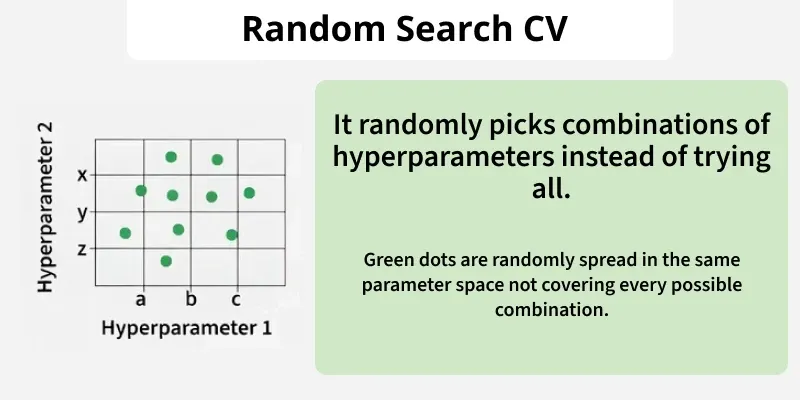

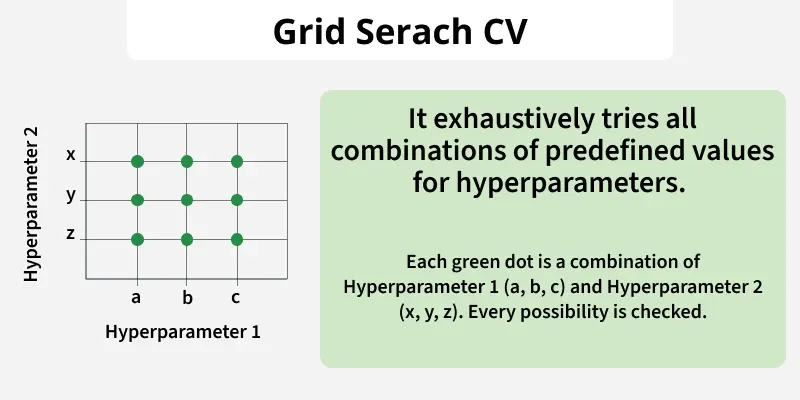

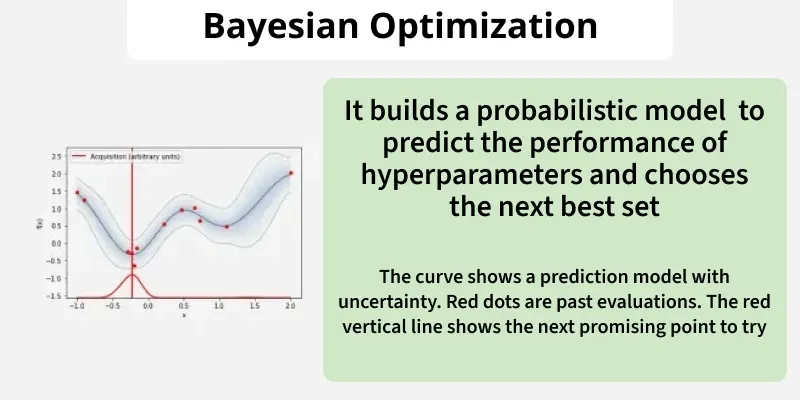

**1. GridSearchCV**

GridSearchCV is a brute-force technique for hyperparameter tuning. It trains the model using all possible combinations of specified hyperparameter values to find the best-performing setup. It is slow and uses a lot of computer power which makes it hard to use with big datasets or many settings. It works using below steps:

1. Create a grid of potential values for each hyperparameter.

2. Train the model for every combination in the grid.

3. Evaluate each model using cross-validation.

4. Select the combination that gives the highest score.

For example if we want to tune two hyperparameters C and penalty for a Logistic Regression Classifier model with the following sets of values:

C = [0.1, 0.2, 0.3, 0.4, 0.5]

penalty = [0.01, 0.1, 0.5, 1.0]

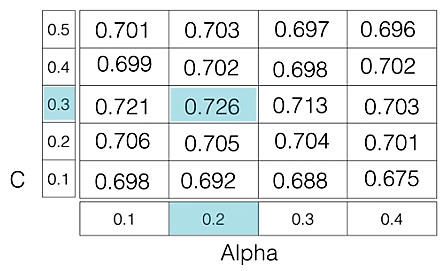

The grid search technique will construct multiple versions of the model with all possible combinations of C and Alpha, resulting in a total of 5 * 4 = 20 different models. The best-performing combination is then chosen.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

c_space = np.logspace(-5, 8, 15)
# -2, -4, -1, 0, ...15 till 8

param_grid = {
    'C': c_space,
    'penalty': ['l1', 'l2']
}

logreg = LogisticRegression(solver='liblinear')

logreg_cv = GridSearchCV(logreg, param_grid, cv=5)

logreg_cv.fit(X, y)

print("Tuned Logistic Regression Parameters: {}".format(logreg_cv.best_params_))
print("Best score is {}".format(logreg_cv.best_score_))

Tuned Logistic Regression Parameters: {'C': np.float64(0.05179474679231213), 'penalty': 'l1'}
Best score is 0.857


**2. RandomizedSearchCV**

As the name suggests RandomizedSearchCV picks random combinations of hyperparameters from the given ranges instead of checking every single combination like GridSearchCV.

1. In each iteration it tries a new random combination of hyperparameter values.

2. It records the model’s performance for each combination.

3. After several attempts it selects the best-performing set.

In [2]:
import numpy as np
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "max_depth": [3, None],
    "max_features": randint(1, 9),
    "min_samples_leaf": randint(1, 9),
    "criterion": ["gini", "entropy"]
}

tree = DecisionTreeClassifier()
tree_cv = RandomizedSearchCV(tree, param_dist, cv=5)
tree_cv.fit(X, y)

print("Tuned Decision Tree Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned Decision Tree Parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 7, 'min_samples_leaf': 2}
Best score is 0.833


**3. Bayesian Optimization**

Grid Search and Random Search can be inefficient because they blindly try many hyperparameter combinations, even if some are clearly not useful. Bayesian Optimization takes a smarter approach. It treats hyperparameter tuning like a mathematical optimization problem and learns from past results to decide what to try next.

1. Build a probabilistic model (surrogate function) that predicts performance based on hyperparameters.

2. Update this model after each evaluation.

3. Use the model to choose the next best set to try.

4. Repeat until the optimal combination is found. The surrogate function models:

P(score(y)∣hyperparameters(x)) 

Here the surrogate function models the relationship between hyperparameters x and the score y. By updating this model iteratively with each new evaluation Bayesian optimization makes more informed decisions. Common surrogate models used in Bayesian optimization include:

Gaussian Processes

Random Forest Regression

Tree-structured Parzen Estimators (TPE)

### **Cross Validation**

k= 5

we need to train our model on 4 subsets and test it on 1 subset

Cross-validation is a technique used to evaluate the performance of a model by partitioning the dataset into subsets, training the model on a portion of the data, and then validating the model on the remaining data. The basic idea behind cross-validation is to use a subset of the data to train the model and another subset to test its performance. This allows the machine learning model to be trained on a variety of data and to generalize better to new data.

There are different types of cross-validation techniques available, but the most commonly used technique is k-fold cross-validation. In k-fold cross-validation, the data is partitioned into k equally sized folds. The model is then trained on k-1 folds and tested on the remaining fold. This process is repeated k times, with each of the k folds used once as the validation data. The final performance of the model is then averaged over the k iterations to obtain an estimate of the model's performance.

**Why is Cross-Validation Important?**

Cross-validation is an essential technique in machine learning because it helps to prevent overfitting or underfitting of a model. Overfitting occurs when the model is too complex and fits the training data too closely, resulting in poor performance on new data. On the other hand, underfitting occurs when the model is too simple and does not capture the underlying patterns in the data, resulting in poor performance on both the training and test data.

Cross-validation also helps to determine the optimal model hyperparameters. Hyperparameters are the settings that control the behavior of the model. For example, in a decision tree algorithm, the maximum depth of the tree is a hyperparameter that determines the level of complexity of the model. By using cross-validation to evaluate the performance of the model at different hyperparameter values, we can select the optimal hyperparameters that maximize the model's performance.

**Implementing Cross-Validation in Python**

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load the Iris dataset
iris = load_iris()

# Split the data into a training set and a test set
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)



In [2]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)

In [3]:
from sklearn.model_selection import cross_val_score

# Perform k-fold cross-validation
scores = cross_val_score(clf, X_train, y_train, cv=5)

In [4]:
import numpy as np

# Calculate the mean and standard deviation of the scores
mean_score = np.mean(scores)
std_score = np.std(scores)

print("Mean cross-validation score: {:.2f}".format(mean_score))
print("Standard deviation of cross-validation score: {:.2f}".format(std_score))

Mean cross-validation score: 0.94
Standard deviation of cross-validation score: 0.06
